#### Non-Negative Matrix Factorization(NMF)

1.  Non Negative Matrix Factorization is an unsupervised machine learning technique used for 

    (a.)    Topic Modelling

    (b.)    Dimensionality Reduction

2.  The main goal of Non negative Matrix Factorization  is to decompose the large matrix into two small matrices such that all the values in the matrices are non-negative. 

3.  The NMF algorithm produces all the positive values as they are very easier to interpret and understand.


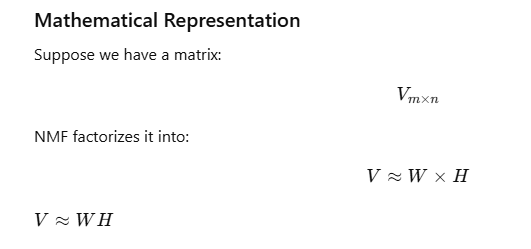


Suppose we have a large matrix V, it has been decomposed into W and H

    (a.)    W ------------->  Feature Matrix

    (b.)    H ------------->  Coefficient Matrix


Ex:----

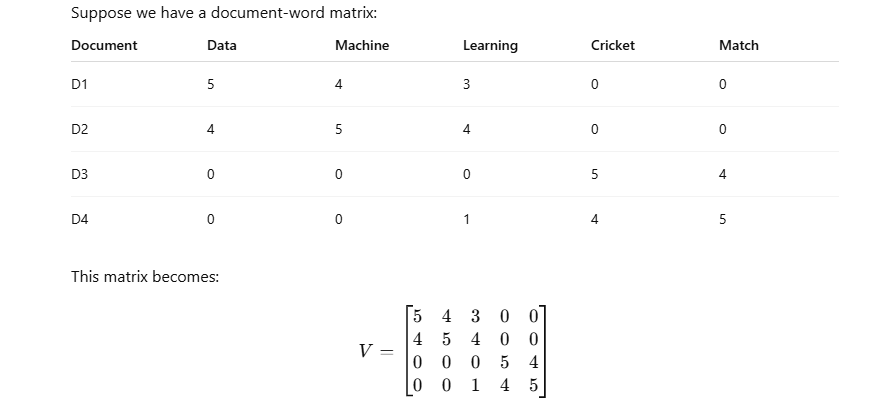


#### Observations:

1.  The above matrix signifies the document word matrix. On applying NMF, it decomposes the matrix into

    (a.)    document-topic matrix

    (b.)    topic-word     matrix


#### Document Topic matrix(W):

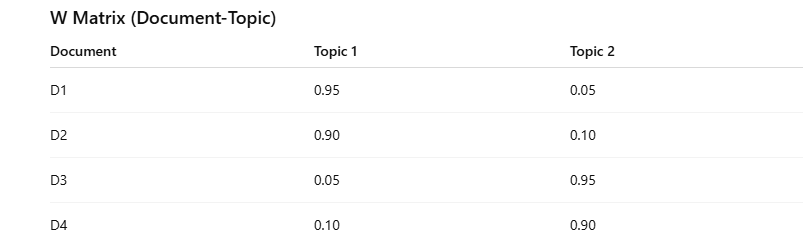


### Topic Word matrix(H): 

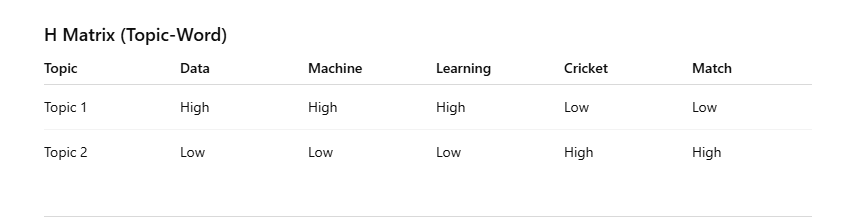    


##### Observations:

1. Initially, we have an original matrix named (V). It is a document word matrix.

2.  On applying NMF on it, the matrix V has been decomposed into

    (a.)    W matrix --------> It represents document - topic matrix

    (b.)    H matrix --------> It represents topic - word matrix


3. In the figure shown for Document Topic matrix, we have the 

    (a.)    list of documents shpwn in the left side

    (b.)    topic with their probabilities in the right side.

4.  In the topic word matrix, we have

    (a.)    list of topics in the left side

    (b.)    words with labels n the right side.

    (c.)    For Topic 1: date, machine, learning has been labelled as high

    (d.)    For Topic 2: Cricket, match has been  labelled as high.



#### Input or Non-Negative Matrix Factorization :---


1.  Input = A Document Word matrix

2.  Output =

    (a.)    Hidden Topics

    (b.)    Topic Keywords

    (c.)    Topic Distribution per document


#### When to use NMF?

Ans:  Non Negative Matrix Fcatorization(NMF) is used:---

        (a.)    when we have the text data

        (b.)    when we want to use tf-idf vectorizer

        (c.)    when we need interpretable topics

        (d.)    dataset is mdeium in size.


#### Step 1: Import all the necessary libraries

In [535]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

import  nltk

from    sklearn.feature_extraction.text import TfidfVectorizer
from    sklearn.decomposition           import NMF

#### OBSERVATIONS:

1.  NMF ----------->  Non-Negative Matrix Factorization decomposes the matrix into two small matrices used for topic modelling.

#### Step 2: Define the dataset

In [536]:
#### define the documents

documents = [
    "I love to eat pizza and pasta",
    "The new movie was fantastic and thrilling",
    "Python is great for data science and machine learning",
    "I enjoy watching movies and eating popcorn",
    "Data scientists use Python for analysis and modeling",
    "The pizza at that restaurant was delicious",
]

In [537]:
documents

['I love to eat pizza and pasta',
 'The new movie was fantastic and thrilling',
 'Python is great for data science and machine learning',
 'I enjoy watching movies and eating popcorn',
 'Data scientists use Python for analysis and modeling',
 'The pizza at that restaurant was delicious']

#### OBSERVATIONS:

1.  It has six documents in the list.

2.  The goal of NMF is to discover the hidden topics from these documents.

#### Step 3: Convert the text into Tfidf Vectorizer

In [538]:
#### Convert the text into Tf-iDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

#### create an object for TfidfVectorizer

tfidf = TfidfVectorizer()

#### using the object for tfidf vectorizer, transform the text
X_vectorized = tfidf.fit_transform(documents)

In [539]:
X_vectorized

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 43 stored elements and shape (6, 33)>

#### OBSERVATIONS:

1.  Here the document list has been converted into the sparse matrix as it can only store all the non zero values and their positions and prevent memory wastage.

In [540]:
#### Convert the sparse matrix into the dense matrix
X_vectorized_dense = X_vectorized.toarray()

In [541]:
X_vectorized_dense

array([[0.        , 0.23062572, 0.        , 0.        , 0.        ,
        0.4501536 , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.4501536 , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.4501536 ,
        0.36913239, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.4501536 ,
        0.        , 0.        , 0.        ],
       [0.        , 0.21635609, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.422301  , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.422301  , 0.        , 0.422301  , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.34629286, 0.422301  , 0.        ,
        0.        , 0.34629286, 0.        ],
       [0.        , 0.18988419, 0.        , 0.30392276, 0.        ,
        0.        , 0.    

In [542]:
X = X_vectorized_dense

In [543]:
X

array([[0.        , 0.23062572, 0.        , 0.        , 0.        ,
        0.4501536 , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.4501536 , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.4501536 ,
        0.36913239, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.4501536 ,
        0.        , 0.        , 0.        ],
       [0.        , 0.21635609, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.422301  , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.422301  , 0.        , 0.422301  , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.34629286, 0.422301  , 0.        ,
        0.        , 0.34629286, 0.        ],
       [0.        , 0.18988419, 0.        , 0.30392276, 0.        ,
        0.        , 0.    

#### OBSERVATIONS:

1.  Here the sparse matrix is converted into the numpy array for better view and visibility.

2.  The new input has become a complete numerical model that can easily be trained by the LDA model.

#### Step 4: Obtain all the vocabularies from the documents

In [544]:
#### Obtain all the vocabularies
vocabularies = tfidf.get_feature_names_out()

In [545]:
vocabularies

array(['analysis', 'and', 'at', 'data', 'delicious', 'eat', 'eating',
       'enjoy', 'fantastic', 'for', 'great', 'is', 'learning', 'love',
       'machine', 'modeling', 'movie', 'movies', 'new', 'pasta', 'pizza',
       'popcorn', 'python', 'restaurant', 'science', 'scientists', 'that',
       'the', 'thrilling', 'to', 'use', 'was', 'watching'], dtype=object)

#### OBSERVATIONS:

1.  It obtaines the list of all the vocabularies from the document list.

#### Step 5: Display the Tf-idf Matrix

In [546]:
#### Display the matrix
tfidf_matrix = pd.DataFrame(
    X                                                    ,
    columns = tfidf.get_feature_names_out()
)

In [547]:
tfidf_matrix

,analysis,and,at,data,delicious,eat,eating,enjoy,fantastic,for,...,restaurant,science,scientists,that,the,thrilling,to,use,was,watching
0,0.000000,0.230626,0.000000,0.000000,0.000000,0.450154,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.450154,0.000000,0.000000,0.000000
1,0.000000,0.216356,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.422301,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.346293,0.422301,0.000000,0.000000,0.346293,0.000000
2,0.000000,0.189884,0.000000,0.303923,0.000000,0.000000,0.000000,0.000000,0.000000,0.303923,...,0.000000,0.370631,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.223332,0.000000,0.000000,0.000000,0.000000,0.435918,0.435918,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.435918
4,0.399051,0.204445,0.000000,0.327228,0.000000,0.000000,0.000000,0.000000,0.000000,0.327228,...,0.000000,0.000000,0.399051,0.000000,0.000000,0.000000,0.000000,0.399051,0.000000,0.000000
5,0.000000,0.000000,0.407662,0.000000,0.407662,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.407662,0.000000,0.000000,0.407662,0.334289,0.000000,0.000000,0.000000,0.334289,0.000000


#### OBSERVATIONS:

1.  The Tf-iDF Matrix is obtained with all the vocabularies as the columns in the dataset and their tf-idf scores in the matrix.

#### Step 6: Apply NMF Model

In [548]:
#### Create the object for NMF
nmf = NMF(
    n_components = 3    ,
    random_state = 42
)

#### OBSERVATIONS:

1.  The object for Non Negative decomposition is created with the following parameters:---

    (a.)    n_components = 3 --------> NMF wants 3 hidden topics to be discovered.

    (b.)    random_state = 42 -------> It ensures reproducibility.

#### Step 7: Train the NMF model

In [549]:
#### Train the model
nmf.fit(X_vectorized_dense)

,"n_components n_components: int or {'auto'} or None, default='auto'Number of components. If `None`, all features are kept.If `n_components='auto'`, the number of components is automatically inferredfrom W or H shapes... versionchanged:: 1.4 Added `'auto'` value... versionchanged:: 1.6 Default value changed from `None` to `'auto'`.",3
,"init init: {'random', 'nndsvd', 'nndsvda', 'nndsvdar', 'custom'}, default=NoneMethod used to initialize the procedure.Valid options:- `None`: 'nndsvda' if n_components <= min(n_samples, n_features), otherwise random.- `'random'`: non-negative random matrices, scaled with: `sqrt(X.mean() / n_components)`- `'nndsvd'`: Nonnegative Double Singular Value Decomposition (NNDSVD) initialization (better for sparseness)- `'nndsvda'`: NNDSVD with zeros filled with the average of X (better when sparsity is not desired)- `'nndsvdar'` NNDSVD with zeros filled with small random values (generally faster, less accurate alternative to NNDSVDa for when sparsity is not desired)- `'custom'`: Use custom matrices `W` and `H` which must both be provided... versionchanged:: 1.1 When `init=None` and n_components is less than n_samples and n_features defaults to `nndsvda` instead of `nndsvd`.",None
,"solver solver: {'cd', 'mu'}, default='cd'Numerical solver to use:- 'cd' is a Coordinate Descent solver.- 'mu' is a Multiplicative Update solver... versionadded:: 0.17 Coordinate Descent solver... versionadded:: 0.19 Multiplicative Update solver.",'cd'
,"beta_loss beta_loss: float or {'frobenius', 'kullback-leibler', 'itakura-saito'}, default='frobenius'Beta divergence to be minimized, measuring the distance between Xand the dot product WH. Note that values different from 'frobenius'(or 2) and 'kullback-leibler' (or 1) lead to significantly slowerfits. Note that for beta_loss <= 0 (or 'itakura-saito'), the inputmatrix X cannot contain zeros. Used only in 'mu' solver... versionadded:: 0.19",'frobenius'
,"tol tol: float, default=1e-4Tolerance of the stopping condition.",0.0001
,"max_iter max_iter: int, default=200Maximum number of iterations before timing out.",200
,"random_state random_state: int, RandomState instance or None, default=NoneUsed for initialisation (when ``init`` == 'nndsvdar' or'random'), and in Coordinate Descent. Pass an int for reproducibleresults across multiple function calls.See :term:`Glossary `.",42
,"alpha_W alpha_W: float, default=0.0Constant that multiplies the regularization terms of `W`. Set it to zero(default) to have no regularization on `W`... versionadded:: 1.0",0.0
,"alpha_H alpha_H: float or ""same"", default=""same""Constant that multiplies the regularization terms of `H`. Set it to zero tohave no regularization on `H`. If ""same"" (default), it takes the same value as`alpha_W`... versionadded:: 1.0",'same'
,"l1_ratio l1_ratio: float, default=0.0The regularization mixing parameter, with 0 <= l1_ratio <= 1.For l1_ratio = 0 the penalty is an elementwise L2 penalty(aka Frobenius Norm).For l1_ratio = 1 it is an elementwise L1 penalty.For 0 < l1_ratio < 1, the penalty is a combination of L1 and L2... versionadded:: 0.17 Regularization parameter *l1_ratio* used in the Coordinate Descent solver.",0.0
,"verbose verbose: int, default=0Whether to be verbose.",0


#### OBSERVATIONS:

1.  After training the NMF model, the model will learn all the NMF decomposition from the data.

2.  Internally the original document word matrix(V) is decomposed into

                (a.) document topic matrix (W)

                (b.) topic word matrix(H)

3.  This decomposition is done so as to extract all the hidden topics from the documents.

#### Step 8: Obtain the document topic matrix

In [550]:
### Get Document-Topic Matrix
W = nmf.transform(X_vectorized_dense)

In [551]:
W

array([[0.04127775, 0.37225501, 0.09669325],
       [0.00869356, 0.67339921, 0.        ],
       [0.53713002, 0.        , 0.        ],
       [0.        , 0.        , 0.89499388],
       [0.53726652, 0.        , 0.        ],
       [0.        , 0.73590058, 0.        ]])

#### OBSERVATIONS:

1.  It obtains the document topic matrix from the original document word matrix.

#### Step 9: Obtain the Topic Word matrix

In [552]:
#### Get the Topic Word matrix
H = nmf.components_

In [553]:
print(H)

[[0.37032426 0.37685161 0.         0.5856433  0.         0.02643562
  0.         0.         0.         0.5856433  0.34386242 0.34386242
  0.34386242 0.02643562 0.34386242 0.37032426 0.         0.
  0.         0.02643562 0.01377329 0.         0.5856433  0.
  0.34386242 0.37032426 0.         0.         0.         0.02643562
  0.37032426 0.         0.        ]
 [0.         0.18880359 0.26465317 0.         0.26465317 0.14578634
  0.         0.         0.25087949 0.         0.         0.
  0.         0.14578634 0.         0.         0.25087949 0.
  0.25087949 0.14578634 0.33702031 0.         0.         0.26465317
  0.         0.         0.26465317 0.42274415 0.25087949 0.14578634
  0.         0.42274415 0.        ]
 [0.         0.26394731 0.         0.         0.         0.04715201
  0.48143753 0.48143753 0.         0.         0.         0.
  0.         0.04715201 0.         0.         0.         0.48143753
  0.         0.04715201 0.02903867 0.48143753 0.         0.
  0.         0.         

#### OBSERVATIONS:

1.  It obtains the topic word matrix from the original document word matrix.

#### Step 10: Get the shape of the decomposed parts

In [554]:
print("Shape of the document topic matrix is:", W.shape)

print("Shape of the topic    word matrix is:",  H.shape)

Shape of the document topic matrix is: (6, 3)
Shape of the topic    word matrix is: (3, 33)


#### OBSERVATIONS:

1. Shape of the document topic matrix indicates (no of documents, no of topics)

    It indicates how strongly each document belons to each topic.

2.  Shape of the topic word matrix(no of topics, no of words)

    It indicates no of topics in each row and no of words in the column.

3.  Higher the value indicates more important words.

#### Step 11: Display the document topic data in the matrix form

In [555]:
W_df = pd.DataFrame(
    W                               ,
    columns = [f"Topic_{i+1}"  for i in range(3)]
)

In [556]:
### Matrix form of document topic
W_df

,Topic_1,Topic_2,Topic_3
0,0.041278,0.372255,0.096693
1,0.008694,0.673399,0.000000
2,0.537130,0.000000,0.000000
3,0.000000,0.000000,0.894994
4,0.537267,0.000000,0.000000
5,0.000000,0.735901,0.000000


#### OBSERVATIONS:

1.  The above dataframe indicates the document topic matrix

    (a.)    where the columns of the dataframe indicates the column names as ['Topic_1', 'Topic_2', 'Topic_3']

    (b.)    each row indicates each document and the values in the matrix species the tfidf scores for each word in the sentences.

2.  From the above dataframe, it is seen that

    (a.)    D3 and D5 belongs to the Topic_1.

    (b.)    D2 and D6 belongs to the Topic_2.

    (c.)    D4 belonds to the Topic_3.

#### Step 12: Get the top five words for each topic

In [557]:
#### Get the Top five words for each topic

##### Get the vocabularies for the list
vocabularies = tfidf.get_feature_names_out()
print(vocabularies)

#### Get the top five words for each topic
for topic_idx,topic in enumerate(H):
    #### print the topic number
    print(f"Topic:{topic_idx}")
    #### get the top five words for each topic
    print([vocabularies[i] for i in topic.argsort()[-5:]])

['analysis' 'and' 'at' 'data' 'delicious' 'eat' 'eating' 'enjoy'
 'fantastic' 'for' 'great' 'is' 'learning' 'love' 'machine' 'modeling'
 'movie' 'movies' 'new' 'pasta' 'pizza' 'popcorn' 'python' 'restaurant'
 'science' 'scientists' 'that' 'the' 'thrilling' 'to' 'use' 'was'
 'watching']
Topic:0
['modeling', 'and', 'for', 'data', 'python']
Topic:1
['that', 'restaurant', 'pizza', 'the', 'was']
Topic:2
['eating', 'enjoy', 'popcorn', 'movies', 'watching']


#### OBSERVATIONS:

1.  We have obtained the top five words for each topic.

#### Step 13: Assign Dominant Topic to Each Document

In [558]:
#### Assign the dominant topic to each document
dominant_topic=W.argmax(axis=1)

In [559]:
dominant_topic

array([1, 1, 0, 2, 0, 1])

#### OBSERVATIONS:

1.  It obtains the column index having the largest value.

In [560]:
#### Assign whcih document is having the dominant topic
for i,topic in enumerate(dominant_topic):
    print(f"Document {i+1} ------> Topic {topic+1}")

Document 1 ------> Topic 2
Document 2 ------> Topic 2
Document 3 ------> Topic 1
Document 4 ------> Topic 3
Document 5 ------> Topic 1
Document 6 ------> Topic 2


#### OBSERVATIONS:

1.  Document 1 is having Topic 2 as the dominant.

2.  Document 2 is having Topic 2 as the dominant.

3.  Document 3 is having Topic 1 as the dominant.

4.  Document 4 is having Topic 3 as the dominant.

5.  Document 5 is having Topic 1 as the dominant.

6.  Document 6 is having Topic 2 as the dominant.

#### CONCLUSIONS:

####  Why is NMF preferred over LDA in some cases?

Ans: NMF works very well with TF-IDF matrices, is computationally faster, and often produces highly interpretable topics because all weights are non-negative. LDA is a probabilistic model and generally works best with count-based document-term matrices rather than TF-IDF.